In [35]:
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from data_analysis import fit_linear_background_iterative
from glob import glob
from scipy.signal import savgol_filter

In [36]:
def reduced_data(filename):
    x, y = load_data(filename, skiprows=18)
    #y = y-(-0.013)
    #a, b, _, _ = fit_linear_background_iterative(x,y, n_iter=3)
    #yf = y/(a* x + b)
    #xf = x
    #original_data = [x, y]

    return x, y


def load_data(file:str, skiprows=18):
    data = np.loadtxt(file, delimiter=',', skiprows=skiprows,  usecols=(3, 4))
    return data[:, 0], data[:,1]


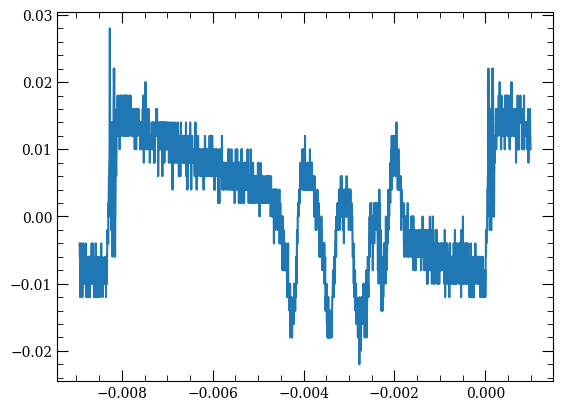

In [37]:
files = np.sort(glob("data_oscilloscope_F4/*/*.CSV"))
xf, yf = reduced_data(files[10])
plt.plot(xf, yf)


In [34]:
transitions = [
    (0,                                        "blue",  "6→5"),
    (127.4,                                    "red",   "5→5"),
    (127.4 + 106.2,                            "blue",  "4→5"),
    (127.4 + 251.1,                            "blue",  "5→4"),
    (127.4 + 106.2 + 251.1,                    "blue",  "4→4"),
    (127.4 + 106.2 + 251.1 + 85,              "blue",  "3→4"),
    (127.4 + 106.2 + 251.1 + 201.3,           "blue",  "4→3"),
    (127.4 + 106.2 + 251.1 + 201.3 + 85,      "blue",  "3→3"),
    (127.4 + 106.2 + 251.1 + 201.3 + 85 + 151.2, "blue", "3→2"),
]

data_oscilloscope_F4/ALL0005/F0005CH3.CSV


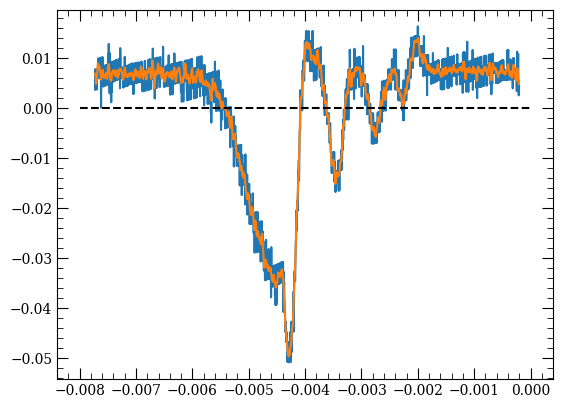

In [39]:
#background
fileb = files[-1]
times, valuesb = load_data(fileb)
smoothedb = savgol_filter(valuesb, window_length=150, polyorder=1)
#plt.plot(times1, smoothed1)

idx=0
file_main = files[idx]
print(file_main)
_, values_data = load_data(file_main)
values = values_data- smoothedb 
smoothed_data = savgol_filter(values, window_length=20, polyorder=5)


plt.plot(times[300:-300], values[300:-300])
plt.plot(times[300:-300], smoothed_data[300:-300])
plt.hlines(0, xmin=-0.008, xmax=0.000, color="black", linestyles="--")
#plt.plot(times, smoothed1)